In [1]:
import numpy as np
import glob
import os

import matplotlib.pyplot as plt

from scripts_fermions.operators import Hamiltonian, Boost
from scripts_fermions.construct_P_state import construct_P_state
import yastn
from yastn.tn import mps


In [2]:
g = 1
N = 256
a = 0.125
m = 0.5
sg2 = 0.25
x0 = 1.5
#
glob_path = os.path.join(os.path.abspath(""), "./results_fermions/g=1.0000/**/state_t=*.npy")
fnames = glob.glob(glob_path, recursive=True)
fns = sorted([fname for fname in fnames if all(x in fname for x in ["/g=1.0000/", "dt=0.0625", f"{N=}", f"{a=:0.4f}", f"{x0=:0.4f}", f"{sg2=:0.4f}", f"{m=:0.4f}"])]);

In [3]:
#
D = 128
ops = yastn.operators.SpinlessFermions(sym='U1', tensordot_policy='no_fusion')
#
glob_path = os.path.join(os.path.abspath(""), "./results_fermions/g=1.0000/**/gs/**/state_D=*.npy")
fnames = glob.glob(glob_path, recursive=True)
fgs = sorted([fname for fname in fnames if all(x in fname for x in ["/g=1.0000/", f"{N=}", f"{a=:0.4f}", f"{D=}", f"{m=:0.4f}"])])
#
def fn_mass(fns, **kwargs):
    return [x for x in fns if all( f"{k}={v}" in x for k, v in kwargs.items())][0]
#
d_gs = np.load(fn_mass(fgs ), allow_pickle=True).item()


In [4]:
d_gs = np.load(fn_mass(fgs, m=m), allow_pickle=True).item()
psi_gs = yastn.from_dict(d_gs['psi'])

H = Hamiltonian(N, m, g, t=0, a=a, v=1, Q=0, ops=ops)
K = Boost(N, m, g, a, ops)
E_gs = mps.vdot(psi_gs, H, psi_gs).real

In [5]:
ts = np.linspace(0, 16, 17)
Ps = [0, 1, 2, 4]
Ds = [256]
PPs = np.linspace(0, 6, 49)


In [6]:
psi_t = {(t, P, D): yastn.from_dict(np.load(fn_mass(fns, t=t, P=P, D=D), allow_pickle=True).item()['psi']) for t in ts for P in Ps for D in Ds}


In [7]:
probs_gs = np.load(f"./overlaps/probs_gs_gauss_{m=}_{N=}_{a=}.npy", allow_pickle=True).item()

In [8]:
data = np.load(f"./results_fermions/construct_P_{m=}_{N=}_{a=}.npy", allow_pickle=True).item()

psi_P = data['state']
eng_P = data['energy']


In [9]:
for k, v in psi_P.items():
    psi_P[k] = yastn.from_dict(v)

In [ ]:

psi_P = {}
eng_P = {}
for PP in PPs:
    print(PP)
    psi_P[PP], eng_P[PP] = construct_P_state(PP, N, m, g, a, psi_gs, ops)

0.0
0.125
0.25
0.375
0.5
0.625
0.75
0.875
1.0
1.125
1.25
1.375
1.5
1.625
1.75
1.875
2.0
2.125
2.25
2.375
2.5
2.625
2.75
2.875
3.0


Text(0, 0.5, 'Energy above gs')

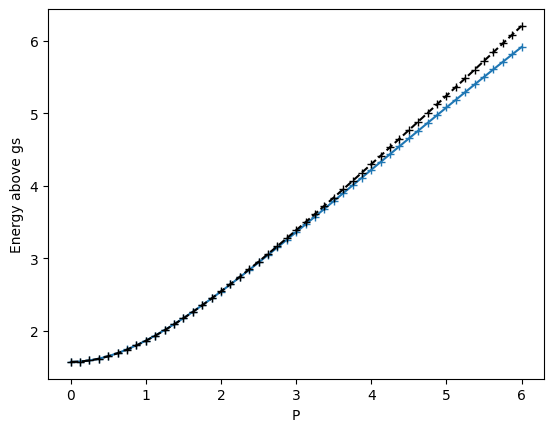

In [10]:
k, v = np.array(list(eng_P.keys())), np.array(list(eng_P.values()))
plt.plot(k, v - E_gs, '-+')
plt.plot(k, np.sqrt((eng_P[0] - E_gs) ** 2 +  k ** 2), '--+k')
plt.xlabel("P")
plt.ylabel("Energy above gs")

In [11]:
probs_R = {}
for (t, P, D), pt in psi_t.items():
    for PP, pc in psi_P.items():
        if (t, P, D, PP) not in probs_R:
            probs_R[t, P, D, PP] = np.abs(mps.vdot(pt, pc)) ** 2


In [12]:
np.save(f"./results_fermions/probs_gauss_R_{m=}_{N=}_{a=}.npy", probs_R, allow_pickle=True)
probs_R = np.load(f"./results_fermions/probs_gauss_R_{m=}_{N=}_{a=}.npy", allow_pickle=True).item()

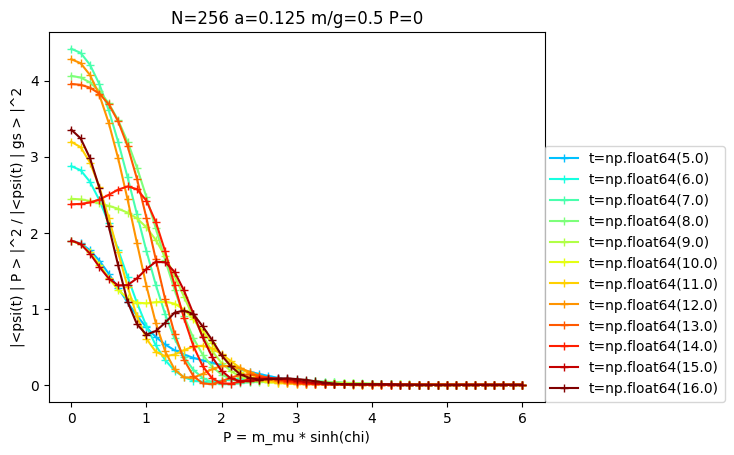

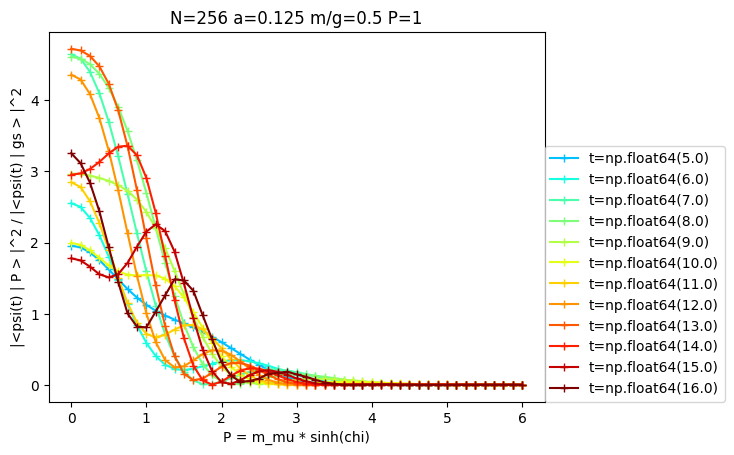

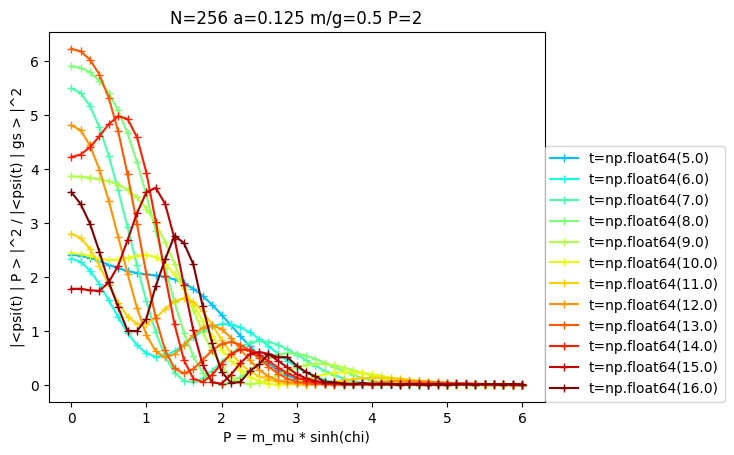

KeyError: (np.float64(5.0), 3, 256, np.float64(0.0))

In [14]:
cm = plt.cm.jet
for P in [0, 1, 2, 3, 4]:
    for D in Ds:
      for t in ts[5:]:
        pr = [probs_R[t, P, D, PP] / probs_gs[t, P, D] for PP in PPs]
        sym = '-+' if D == Ds[0] else '-o'
        line, = plt.plot(PPs, pr, sym, color = cm(t / ts[-1]))
        if D == Ds[0]:
          line.set_label(f"{t=}")
    plt.xlabel('P = m_mu * sinh(chi)')
    plt.ylabel("|<psi(t) | P > |^2 / |<psi(t) | gs > |^2")
    plt.legend(loc=(1, 0))
    #plt.xlim([0, 2])
    plt.title(f"{N=} {a=} {m/g=} {P=}")
    #plt.ylim([1e-3, 1e1])
    plt.show()